In [1]:
import numpy as np, matplotlib.pyplot as plt, time
from astropy.table import Table

# Import nuGundam related classes
from nugundam import (acf, ang_auto_counts, ang_cross_counts, read_result, plot_compare_ratio, 
     AngularAutoConfig, AngularCrossConfig, AngularAutoCountsConfig, AngularCrossCountsConfig,
     AngularBinning, AngularGridSpec, CatalogColumns, WeightSpec, SplitRandomSpec, BootstrapSpec)
# Import utilities to create mock datasets
from nugundam import aux_mock as mk

# Angular correlations and pair counts with nu-Gundam
-----------------
This notebook is a quick tutorial of how to calculate auto and cross correlations in angular space, as well as individual pair counts such as DD, RR or DR

## Generate mock data and random datasets

Instead of distributing large files, nuGundam includes convenient auxiliary routines to generate toy datasets for testing purposes. Note these mocks are useful and sometimes look realistic, but are not scientifically accurrate.

We generate the ``clustered data sample`` by creating a mock light cone with filamentary structure. The parameters below will give ~250k sources distributed over a 60x60 deg2 region. Feel free to tune them if you like. 

In [23]:
ralim  = [0,60]            # ra limits
declim = [0,60]            # dec limits
zlim   = [0.01,0.15]       # redshift limits
data = mk.mcone_filam(ralim, declim, zlim, npts=80000, nvoids=800, nstep=100, b=150.)

-------------------------------------------------------------
Building cube
  |-- Total objects in cube : 34674
-------------------------------------------------------------
-------------------------------------------------------------
Filling light cone with cubes
  Cube 0 inside cone
    |---  (x0,y0,z0,d0) =  (np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0))
    |---  (x1,y1,z1,d1) =  (np.float64(150.0), np.float64(150.0), np.float64(150.0), np.float64(259.8076211353316))
  Cube 1 inside cone
    |---  (x0,y0,z0,d0) =  (np.float64(0.0), np.float64(0.0), np.float64(150.0), np.float64(150.0))
    |---  (x1,y1,z1,d1) =  (np.float64(150.0), np.float64(150.0), np.float64(300.0), np.float64(367.4234614174767))
  Cube 2 inside cone
    |---  (x0,y0,z0,d0) =  (np.float64(0.0), np.float64(0.0), np.float64(300.0), np.float64(300.0))
    |---  (x1,y1,z1,d1) =  (np.float64(150.0), np.float64(150.0), np.float64(450.0), np.float64(497.49371855331))
  Cube 3 inside cone
    |---

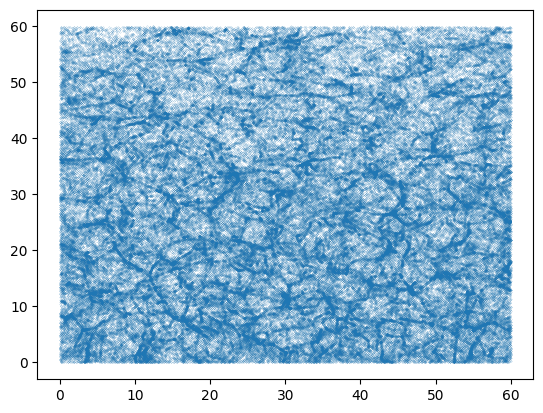

In [4]:
# Plot sky positions
plt.scatter(data['ra'], data['dec'], s=0.01)

Then we add a ``weight`` column (in this case a number proportional to sky density) to emulate an object weight of arbitrary nature. This will be used to properly weight pairs in auto and cross-correlations. 

In [4]:
data = mk.add_mock_weights(data, wmin=0.8, wmax=1.2)

Now generate a ``random sample`` of 1 million sources distributed over the exact same area

In [5]:
rra, rdec = mk.make_random_sphere(1_000_000, seed=42, ralim=ralim, declim=declim)
rans = Table([rra,rdec], names=['ra','dec'])

---------------
**We have just generated two astropy tables (`data` and `rans`) containing mock samples with the columns relevant for the computation.**

----------------

## 1. Create configuration

First we need to create a configuration object which is designed to hold several specifications of the computation to perform. In this case it corresponds to an angular auto-correlation so we use a config object of type ``AngularAutoConfig``. This is where you specify the estimator chosen, the binning for counting, the counting grid, the name of relevant columns in the datasets, and various other parameters.

In [21]:
config1 = AngularAutoConfig(
    # Choose estimator > NAT, DP, LS
    estimator = "LS",
    # Select dataset columns
    columns_data = CatalogColumns(ra="ra", dec="dec"),
    columns_random = CatalogColumns(ra="ra", dec="dec"),
    # Set number of threads
    nthreads = 4,
    # Specify binning > number_of_bins, minimum theta [deg], bin size (in dex if logsep=True)
    binning = AngularBinning.from_binsize(nsep=24, sepmin=30./3600., dsep=0.1, logsep=True),
    # Choose counting grid and ordering 
    grid = AngularGridSpec(autogrid=True, pxorder="cell-dec"),
    # Choose weight model > "auto", "weighted", "unweighted"
    weights = WeightSpec(weight_mode="unweighted"),
    # Enable boostrap error module
    bootstrap = BootstrapSpec(enabled=True, nbts=50, bseed=12345),
)

For convenience, bins can be specified in two ways:
* ``from_binsize`` : by bin size, starting value and the number of bins
* ``from_limits`` : by starting value, end value and the number of bins 

In [14]:
# Example of alternate bin definition
alternate_binning = AngularBinning.from_limits(nsep=30, sepmin=0.01, sepmax=8.)
alternate_binning

AngularBinning(log, 30 bins, sepmin=0.01, sepmax=8, dsep=0.0967697 dex)

Bins can be insepected in several ways before actually performing any calculation

In [8]:
config1.binning

AngularBinning(log, 24 bins, sepmin=0.00833333, sepmax=2.09324, dsep=0.1 dex)

In [9]:
config1.binning.centers

array([0.00935015, 0.01177115, 0.014819  , 0.01865601, 0.02348652,
       0.02956778, 0.03722363, 0.04686178, 0.05899548, 0.07427091,
       0.09350154, 0.11771146, 0.14818995, 0.18656009, 0.23486524,
       0.29567782, 0.37223633, 0.46861777, 0.58995482, 0.74270912,
       0.93501538, 1.17711462, 1.48189951, 1.86560095])

In [10]:
config1.binning.table()

```text
 i        left        right       center       width
 0  0.00833333    0.010491  0.00935015         0.1
 1    0.010491   0.0132074   0.0117711         0.1
 2   0.0132074   0.0166272    0.014819         0.1
 3   0.0166272   0.0209324    0.018656         0.1
 4   0.0209324   0.0263523   0.0234865         0.1
 5   0.0263523   0.0331756   0.0295678         0.1
 6   0.0331756   0.0417656   0.0372236         0.1
 7   0.0417656   0.0525798   0.0468618         0.1
 8   0.0525798    0.066194   0.0589955         0.1
 9    0.066194   0.0833333   0.0742709         0.1
10   0.0833333     0.10491   0.0935015         0.1
11     0.10491    0.132074    0.117711         0.1
12    0.132074    0.166272     0.14819         0.1
13    0.166272    0.209324     0.18656         0.1
14    0.209324    0.263523    0.234865         0.1
15    0.263523    0.331756    0.295678         0.1
16    0.331756    0.417656    0.372236         0.1
17    0.417656    0.525798    0.468618         0.1
18    0.525798     0.66194    0.589955         0.1
19     0.66194    0.833333    0.742709         0.1
20    0.833333      1.0491    0.935015         0.1
21      1.0491     1.32074     1.17711         0.1
22     1.32074     1.66272      1.4819         0.1
23     1.66272     2.09324      1.8656         0.1
```

## 2. Run correlation

Pass the data, randoms and configuration to ``acf`` to perform a correlation run and obtain a result object, in this case of type ``AngularCorrelationResult``. Once finished, it will contain all the counts, bins, correlation function, errors and relevant metadata

In [12]:
ti = time.time()
result1 = acf(data, rans, config1)
print(f'elapsed time [s]: {time.time()-ti:.3f}')

[acf] preparing data and randoms
[acf] counting DD / RR / DR with estimator=LS


[acf] estimating correlation
[acf] done
elapsed time [s]: 5.653


In [16]:
result1.wtheta

array([3.22192957, 3.08225601, 3.0193846 , 2.76748441, 2.50969244,
       2.23456097, 1.82619511, 1.46828369, 1.09824897, 0.82927282,
       0.64882846, 0.53186457, 0.43144467, 0.35247249, 0.2920642 ,
       0.23960368, 0.1940555 , 0.15618291, 0.12068726, 0.08820989,
       0.06112117, 0.03789084, 0.01888955, 0.00367729])

In [17]:
result1.theta_centers

array([0.00935015, 0.01177115, 0.014819  , 0.01865601, 0.02348652,
       0.02956778, 0.03722363, 0.04686178, 0.05899548, 0.07427091,
       0.09350154, 0.11771146, 0.14818995, 0.18656009, 0.23486524,
       0.29567782, 0.37223633, 0.46861777, 0.58995482, 0.74270912,
       0.93501538, 1.17711462, 1.48189951, 1.86560095])

In [18]:
result1.counts.dd

array([5.8280000e+03, 8.9590000e+03, 1.4002000e+04, 2.0849000e+04,
       3.0789000e+04, 4.4958000e+04, 6.2436000e+04, 8.6225000e+04,
       1.1624800e+05, 1.6029400e+05, 2.2916400e+05, 3.3614000e+05,
       4.9809700e+05, 7.4617700e+05, 1.1277040e+06, 1.7095670e+06,
       2.6065090e+06, 3.9864150e+06, 6.1110100e+06, 9.3663430e+06,
       1.4401636e+07, 2.2188477e+07, 3.4258752e+07, 5.2958627e+07])

The correlation function can be plotted directly from its result object

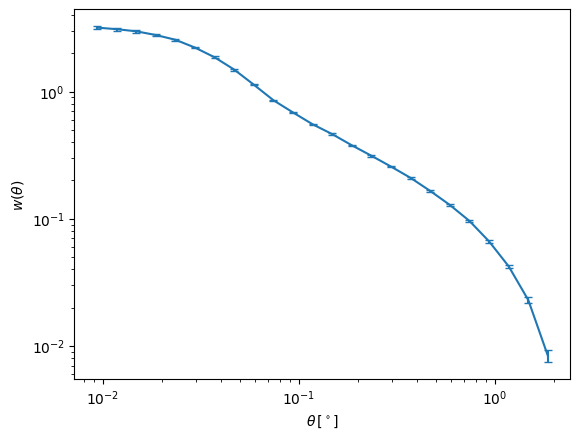

In [11]:
result1.plot();

## 3. Save/read results

Result objects are designed to contain all the information of a given run, so they are the natural way of persisting correlations to disk. You can use the ``save`` or ``save_result`` method  

In [12]:
result1.save('result1.gres')

To read results back use ``read_result()``

In [14]:
result1_readback = read_result('result1.gres')
result1_readback.counts.rr

array([2.12820000e+04, 3.38440000e+04, 5.35300000e+04, 8.54040000e+04,
       1.35204000e+05, 2.13724000e+05, 3.39288000e+05, 5.37731000e+05,
       8.51024000e+05, 1.34845200e+06, 2.13898000e+06, 3.38728100e+06,
       5.36548400e+06, 8.49654900e+06, 1.34488500e+07, 2.12913240e+07,
       3.36705350e+07, 5.32632990e+07, 8.41794560e+07, 1.32942321e+08,
       2.09766062e+08, 3.30633630e+08, 5.20323501e+08, 8.17309875e+08])

Results can be exported as plain ASCII files too

In [15]:
result1.to_ascii('result1.ascii')

## 4. Run a weighted correlation

In [20]:
config2 = AngularAutoConfig(
    # Choose estimator > NAT, DP, LS
    estimator = "LS",
    # Select dataset columns
    columns_data = CatalogColumns(ra="ra", dec="dec", weight='weight'),
    columns_random = CatalogColumns(ra="ra", dec="dec"),
    # Set number of threads
    nthreads = 4,
    # Specify binning > number_of_bins, minimum theta [deg], bin size (in dex if logsep=True)
    binning = AngularBinning.from_binsize(nsep=24, sepmin=30./3600., dsep=0.1, logsep=True),
    # Choose counting grid and ordering 
    grid = AngularGridSpec(autogrid=True, pxorder="cell-dec"),
    # Choose weight model > "auto", "weighted", "unweighted"
    weights = WeightSpec(weight_mode="weighted"),
    # Enable boostrap error module
    bootstrap = BootstrapSpec(enabled=True, nbts=50, bseed=12345),
)

In [18]:
ti = time.time()
result2 = acf(data, rans, config2)
print(f'elapsed time [s]: {time.time()-ti:.3f}')

[acf] preparing data and randoms
[acf] counting DD / RR / DR with estimator=LS


[acf] estimating correlation
[acf] done
elapsed time [s]: 5.806


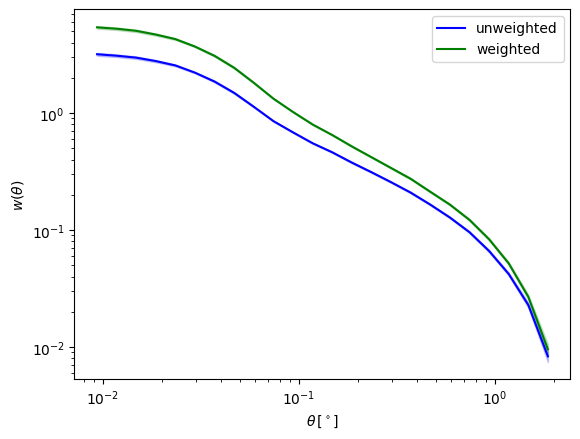

In [19]:
result1.plot(color='b', label='unweighted', errors='band')
result2.plot(color='g', label='weighted', errors='band')
plt.legend();

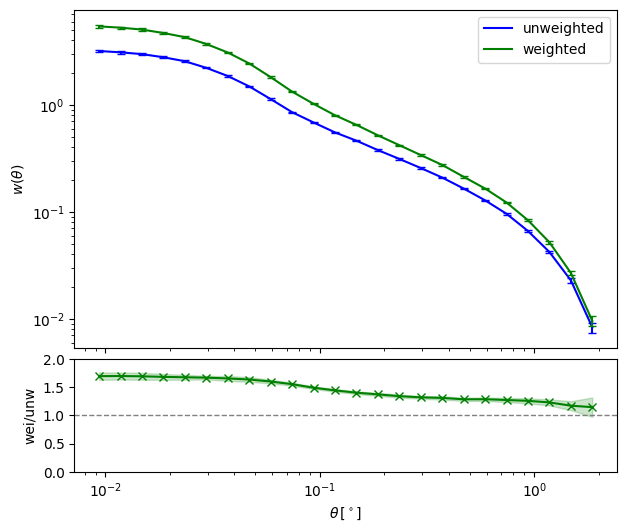

In [20]:
# Create pcf plot with ratio panel below
fig, (ax, rax) = plot_compare_ratio(
    curves=[
        {"key": "unweighted", "result": result1, "label": "unweighted", "color": "b", 'errors':'bar'},
        {"key": "weighted", "result": result2, "label": "weighted", "color":"g", 'errors':'bar'},
    ],
    ratios=[
        {"numerator": "weighted", "denominator": "unweighted", "label": "wei/unw", "marker": "x",'color':'g', "errors":"band"},
    ],
    ratio_ylabel="wei/unw",
    mask_nonpositive=False
)
rax.set_ylim([0,2]);

## 5. Splitting randoms

In many correlation-function measurements, the runtime is dominated by the random–random (RR) counts. When the random catalog is very large, nuGundam can speed up the calculation through a random-split strategy: the full random sample is divided into several smaller, spatially matched subsamples R_s, the counts are computed in each subsample, and the partial results are then combined with the proper normalization to reconstruct the full RR term. This method has been shown to preserve the bias and variance properties of the Landy–Szalay estimator at medium and large scales ([Keihänen et al. 2019](https://ui.adsabs.harvard.edu/abs/2019A%26A...631A..73K/abstract)), while causing only a minor impact on the clustering estimate at the smallest scales.

**(i) Create first a large 10 million random sample**

In [21]:
rra, rdec = mk.make_random_sphere(10_000_000, seed=42, ralim=ralim, declim=declim)
rans_big = Table([rra,rdec], names=['ra','dec'])

**(ii) For comparison, we estimate the acf without any split**

In [23]:
ti = time.time()
result1_nosplit = acf(data, rans_big, config1)
print(f'elapsed time [s]: {time.time()-ti:.3f}')

[acf] preparing data and randoms
[acf] counting DD / RR / DR with estimator=LS


[acf] estimating correlation
[acf] done
elapsed time [s]: 211.356


**(iii) Now enable the ``SplitRandomSpec`` module in the configuration and run the correlation as usual**

In [22]:
config_rsplit = AngularAutoConfig(
    # Choose estimator > NAT, DP, LS
    estimator = "LS",
    # Select dataset columns
    columns_data = CatalogColumns(ra="ra", dec="dec"),
    columns_random = CatalogColumns(ra="ra", dec="dec"),
    # Set number of threads
    nthreads = 4,
    # Specify binning > number_of_bins, minimum theta [deg], bin size (in dex if logsep=True)
    binning = AngularBinning.from_binsize(nsep=24, sepmin=30./3600., dsep=0.1, logsep=True),
    # Choose counting grid and ordering 
    grid = AngularGridSpec(autogrid=True, pxorder="cell-dec"),
    # Choose weight model > "auto", "weighted", "unweighted"
    weights = WeightSpec(weight_mode="unweighted"),
    # Enable boostrap error module
    bootstrap = BootstrapSpec(enabled=True, nbts=50, bseed=12345),
    # Enable split random module > mode can be match_data, nchunks or chunk_size
    split_random=SplitRandomSpec(enabled=True, mode="match_data", seed=12345)
)

In [25]:
ti = time.time()
result1_rsplit = acf(data, rans_big, config_rsplit)
print(f'elapsed time [s]: {time.time()-ti:.3f}')

[acf] preparing data and randoms
[acf] counting DD / RR / DR with estimator=LS


[acf] estimating correlation
[acf] done
elapsed time [s]: 27.244


In [41]:
# Write down you wall times below. In out test we got a ~8X increase in performance at negligible cost in LS precision
full_random_wtime = 211.
split_random_wtime = 27.
print(f'Speedup factor of {full_random_wtime/split_random_wtime:.3f} for nran/nran_split = {len(rans_big)/len(data):.3f}')

Speedup factor of 7.815 for nran/nran_split = 39.225


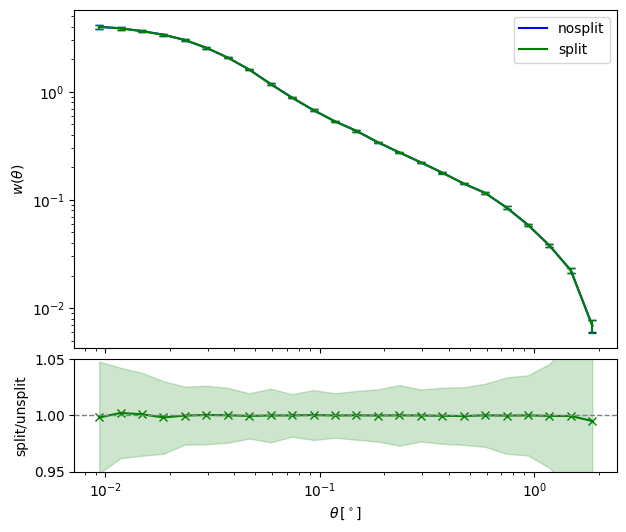

In [40]:
fig, (ax, rax) = plot_compare_ratio(
    curves=[
        {"key": "nosplit", "result": result1_nosplit, "label": "nosplit", "color": "b", 'errors':'bar'},
        {"key": "split", "result": result1_rsplit, "label": "split", "color":"g", 'errors':'bar'},
    ],
    ratios=[
        {"numerator": "split", "denominator": "nosplit", "label": "split/nosplit", "marker": "x",'color':'g', "errors":"band"},
    ],
    ratio_ylabel="split/unsplit",
    mask_nonpositive=False
)
rax.set_ylim([0.95,1.05]);

By default the ``SplitRandomSpec`` module works in ``mode="match_data"``, so that each random subsample will be roughly the size of the data sample. Alternatively, you can set ``mode=nchunks`` and set ``nchunks`` to request an arbitrary number of random subsambles. There is also a third option, ``mode=chunk_size``, so that each subsamble contains ``chunk_size`` objects.

## 6. Individual angular counts

nuGundam can also perform pair counts suc as DD, RR, DR between any two samples. You just need to use the appropiate configuration object (``AngularAutoCountsConfig``, ``AngularCrossCountsConfig``) and call the corresponding count wrapper (``ang_auto_counts``, ``ang_cross_counts``)

In [20]:
config_autocnt = AngularAutoCountsConfig(
    columns=CatalogColumns(ra="ra", dec="dec"),
    binning = AngularBinning.from_binsize(nsep=24, sepmin=30./3600., dsep=0.1, logsep=True),
    grid=AngularGridSpec(autogrid=True, pxorder="cell-dec"),
    weights=WeightSpec(weight_mode="unweighted"),
    bootstrap=BootstrapSpec(enabled=False),
    nthreads=4)

In [26]:
result_autocnt = ang_auto_counts(data, config_autocnt)

[ang_auto_counts] preparing data
[ang_auto_counts] counting DD(theta)


In [27]:
result_autocnt.dd

array([5.8280000e+03, 8.9590000e+03, 1.4002000e+04, 2.0849000e+04,
       3.0789000e+04, 4.4958000e+04, 6.2436000e+04, 8.6225000e+04,
       1.1624800e+05, 1.6029400e+05, 2.2916400e+05, 3.3614000e+05,
       4.9809700e+05, 7.4617700e+05, 1.1277040e+06, 1.7095670e+06,
       2.6065090e+06, 3.9864150e+06, 6.1110100e+06, 9.3663430e+06,
       1.4401636e+07, 2.2188477e+07, 3.4258752e+07, 5.2958627e+07])

In [30]:
config_crosscnt = AngularCrossCountsConfig(
    columns1=CatalogColumns(ra="ra", dec="dec"),
    columns2=CatalogColumns(ra="ra", dec="dec"),
    binning = AngularBinning.from_binsize(nsep=24, sepmin=30./3600., dsep=0.1, logsep=True),
    grid=AngularGridSpec(autogrid=True, pxorder="cell-dec"),
    weights=WeightSpec(weight_mode="unweighted"),
    bootstrap=BootstrapSpec(enabled=False),
    nthreads=4)

In [31]:
result_crosscnt = ang_cross_counts(data, rans, config_crosscnt)


[ang_cross_counts] preparing data
[ang_cross_counts] counting D1D2(theta)


In [32]:
result_crosscnt.d1d2

array([1.07980000e+04, 1.71650000e+04, 2.73480000e+04, 4.32730000e+04,
       6.86980000e+04, 1.09032000e+05, 1.73378000e+05, 2.73941000e+05,
       4.34572000e+05, 6.87332000e+05, 1.09025400e+06, 1.72258900e+06,
       2.73126800e+06, 4.32919700e+06, 6.85029400e+06, 1.08327160e+07,
       1.71415960e+07, 2.70940630e+07, 4.28401550e+07, 6.76410880e+07,
       1.06698450e+08, 1.68131205e+08, 2.64525032e+08, 4.15329533e+08])

## 7. Self describing configurations

nuGundam config classes include a ``.describe()`` class method for interactive API discovery. It summarizes the available fields and their meaning, and with recursive=True it expands nested config sections so you can inspect an entire configuration schema from a notebook. This is useful to quickly check what modules are available in each configuration, an which parameters are exposed.

In [16]:
AngularBinning.describe()

```text
AngularBinning
--------------
nsep : int = Number of angular separation bins.
sepmin : float = Lower edge of the first angular bin in the native angular unit.
dsep : float = Resolved bin width; in dex when logsep=True, otherwise linear.
logsep : bool = Use logarithmic angular bins if True, linear bins otherwise.

Constructors
------------
from_binsize(nsep=36, sepmin=0.01, dsep=0.1, logsep=True)
from_limits(nsep=36, sepmin=0.01, sepmax=10.0, logsep=True)

Resolved instance attributes
----------------------------
edges, centers, widths, sepmax

Instance helpers
----------------
table() -> plain-text table of the resolved bins
```

In [18]:
AngularAutoConfig.describe()

```text
AngularAutoConfig
-----------------
estimator : Literal['NAT', 'DP', 'LS'] = Angular auto-correlation estimator: 'NAT', 'DP', or 'LS'.
columns_data : CatalogColumns = Column names for the data catalog.
columns_random : CatalogColumns = Column names for the random catalog.
binning : AngularBinning = Angular separation binning specification.
grid : AngularGridSpec = Grid / linked-list preparation options for pair counting.
weights : WeightSpec = Weight handling options.
bootstrap : BootstrapSpec = Bootstrap uncertainty options.
jackknife : JackknifeSpec = Jackknife uncertainty options.
progress : ProgressSpec = Progress-reporting options.
split_random : SplitRandomSpec = Optional split-random RR acceleration for LS auto-correlations.
nthreads : int = Number of OpenMP threads; -1 lets the runtime choose.
description : str = Optional free-form description stored with the run metadata.
```

In [19]:
AngularAutoConfig.describe(recursive=True)

```text
AngularAutoConfig
-----------------
estimator : Literal['NAT', 'DP', 'LS'] = Angular auto-correlation estimator: 'NAT', 'DP', or 'LS'.
columns_data : CatalogColumns = Column names for the data catalog.

  CatalogColumns
  --------------
  ra : str = Right ascension column name.
  dec : str = Declination column name.
  weight : str = Weight column name.
  region : str | None = Optional jackknife-region column name.
columns_random : CatalogColumns = Column names for the random catalog.

  CatalogColumns
  --------------
  ra : str = Right ascension column name.
  dec : str = Declination column name.
  weight : str = Weight column name.
  region : str | None = Optional jackknife-region column name.
binning : AngularBinning = Angular separation binning specification.

  AngularBinning
  --------------
  nsep : int = Number of angular separation bins.
  sepmin : float = Lower edge of the first angular bin in the native angular unit.
  dsep : float = Resolved bin width; in dex when logsep=True, otherwise linear.
  logsep : bool = Use logarithmic angular bins if True, linear bins otherwise.
  
  Constructors
  ------------
  from_binsize(nsep=36, sepmin=0.01, dsep=0.1, logsep=True)
  from_limits(nsep=36, sepmin=0.01, sepmax=10.0, logsep=True)
  
  Resolved instance attributes
  ----------------------------
  edges, centers, widths, sepmax
  
  Instance helpers
  ----------------
  table() -> plain-text table of the resolved bins
grid : AngularGridSpec = Grid / linked-list preparation options for pair counting.

  AngularGridSpec
  ---------------
  autogrid : bool | Literal['legacy', 'adaptive'] = Grid selection mode: False uses user-supplied mxh1/mxh2, True or 'legacy' uses the original nuGUNDAM heuristic, and 'adaptive' uses the newer runtime-aware count-box probe.
  mxh1 : int = Requested grid size along the first angular dimension when autogrid=False.
  mxh2 : int = Requested grid size along the second angular dimension when autogrid=False.
  dens : float | None = Optional target particle density used by automatic grid builders.
  pxorder : str = Preparatory memory ordering: 'none' keeps the input order, 'natural' follows the exact counter grid order, and 'cell-dec' additionally sorts within each cell by declination.
  coarse_bins : int = Nominal coarse count-box resolution used by the adaptive autogrid. Values around 16-64 keep the geometry probe cheap while still capturing patchy footprints.
weights : WeightSpec = Weight handling options.

  WeightSpec
  ----------
  weight_mode : Literal['auto', 'weighted', 'unweighted'] = Weight handling mode: 'auto', 'weighted', or 'unweighted'.
  data_col : str = Weight column name for the primary data catalog in auto-correlation runs.
  random_col : str | None = Weight column name for the random catalog; None reuses the data convention when appropriate.
  data1_col : str = Weight column name for the first data catalog in cross-correlation runs.
  data2_col : str = Weight column name for the second data catalog in cross-correlation runs.
bootstrap : BootstrapSpec = Bootstrap uncertainty options.

  BootstrapSpec
  -------------
  enabled : bool = Enable bootstrap resampling for uncertainty estimates.
  nbts : int = Number of bootstrap resamples.
  bseed : int = Random seed used for bootstrap resampling.
  mode : Literal['none', 'primary', 'both'] = Bootstrap strategy: 'none', 'primary', or 'both'.
  primary : Literal['data1', 'data2'] = Primary sample used by cross-correlation bootstrap schemes.
jackknife : JackknifeSpec = Jackknife uncertainty options.

  JackknifeSpec
  -------------
  enabled : bool = Enable jackknife uncertainty estimation.
  nregions : int | None = Number of jackknife regions; None chooses a practical default from the binning.
  generator : Literal['kmeans'] = Automatic region generator used when no region columns are supplied.
  geometry_from : Literal['auto', 'randoms', 'data'] = Catalog family used to derive automatic region geometry.
  seed : int = Random seed used when generating automatic jackknife regions.
  cross_patch_weight : Literal['simple'] = Patch weighting strategy. Only 'simple' is implemented in v39.
  return_cov : bool = Return the full jackknife covariance matrix.
  return_realizations : bool = Return leave-one-region-out realizations in the final result.
progress : ProgressSpec = Progress-reporting options.

  ProgressSpec
  ------------
  enabled : bool = Enable runtime progress reporting.
  progress_file : str | None = Optional path for progress messages; None uses the default backend behavior.
  poll_interval : float = Polling interval in seconds for notebook progress watchers.
split_random : SplitRandomSpec = Optional split-random RR acceleration for LS auto-correlations.

  SplitRandomSpec
  ---------------
  enabled : bool = Enable split-random RR counting for auto LS runs.
  mode : Literal['match_data', 'nchunks', 'chunk_size'] = How to choose the random subcatalog sizes: match the data size, request a fixed number of chunks, or request a target chunk size.
  nchunks : int | None = Requested number of random chunks when mode='nchunks'.
  chunk_size : int | None = Requested chunk size when mode='chunk_size'.
  seed : int = Random seed used to shuffle the prepared random catalog before assigning chunks.
nthreads : int = Number of OpenMP threads; -1 lets the runtime choose.
description : str = Optional free-form description stored with the run metadata.
```

## 8. IO formats

In the example above we generated a toy dataset in the form of two astropy tables with appropiate columns. nuGundam accepts several common table-like catalog formats at the high-level API :

* Astropy tables
* pandas DataFrames
* PyArrow tables
* NumPy structured arrays/recarrays
* Python mappings of the form dict[str, array]

The package accesses data through named columns, configured with objects such as `CatalogColumns`, so the container type can vary as long as it provides the required fields. For angular measurements this usually means `ra` and `dec` plus optional columns such as `weight` or region labels. For projected measurements you additionally provide a distance or redshift-related column, depending on the configuration. Internally, nuGundam extracts the requested columns and converts them to 1-D NumPy arrays before feeding the optimized counters.